# How it works: the machinery, one piece at a time

Safe-ICE has four moving parts. This notebook shows each of them acting on a
real run, using the diagnostics the estimator records in `ice.history`.

1. a **smoothed indicator** $\Phi(-g(u)/\sigma)$, which replaces the hard
   failure test so that every sample carries information, not just the
   failures;
2. a **schedule for $\sigma$**, which sharpens that indicator only as fast as
   the proposal can follow;
3. a **penalised EM step**, which fits the proposal and prunes components it
   does not need;
4. a **heavy-tailed safety component**, mixed in with weight $1 - \lambda$,
   which keeps the proposal's tails heavier than the target's.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from safe_ice import SafeICE
from safe_ice.distributions.nakagami import (
    InverseNakagamiDistribution,
    NakagamiDistribution,
)
from safe_ice.problems.benchmarks import BenchmarkProblems

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "figure.facecolor": "white"})

limit_state = BenchmarkProblems.four_mode_series_system(z=1.0)
REFERENCE = 6.465e-05

## 1. The smoothed indicator

The quantity being estimated involves $\mathbb{1}\{g(u) \le 0\}$, which is
zero for almost every sample when failure is rare — so almost every sample
tells the fitting step nothing. Replacing it with $\Phi(-g/\sigma)$ gives a
gradient to follow, and recovers the indicator as $\sigma \to 0$.

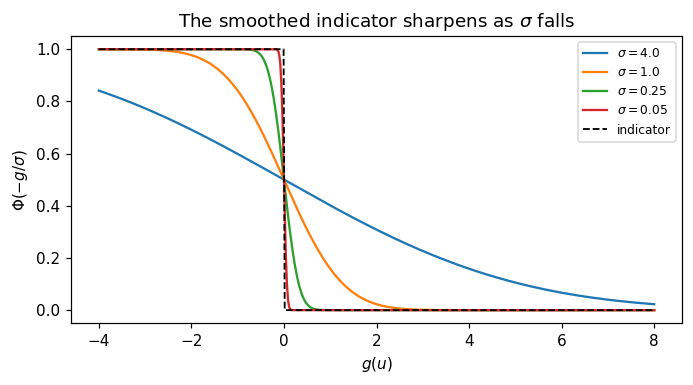

In [2]:
g_axis = np.linspace(-4, 8, 500)
fig, ax = plt.subplots(figsize=(6.4, 3.6))
for sigma in (4.0, 1.0, 0.25, 0.05):
    ax.plot(g_axis, stats.norm.cdf(-g_axis / sigma), label=f"$\\sigma={sigma}$")
ax.plot(g_axis, (g_axis <= 0).astype(float), "k--", lw=1.2, label="indicator")
ax.set(
    xlabel="$g(u)$",
    ylabel=r"$\Phi(-g/\sigma)$",
    title="The smoothed indicator sharpens as $\\sigma$ falls",
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2. The schedule for sigma

Each iteration picks the largest $\sigma$ at which the coefficient of
variation of the weights reaches a target. Falling too fast is the failure
mode: the indicator sharpens onto a region the proposal has not reached yet,
the weights degenerate, and the run never recovers.

In [3]:
ice = SafeICE(
    limit_state_function=limit_state,
    dimension=2,
    N=1000,
    max_iterations=15,
    random_state=3,
)
pf, results = ice.run(verbose=False)
history = ice.history

print(f"estimate   : {pf:.4e}   ({pf / REFERENCE:.2f}x the reference)")
print(f"iterations : {len(history['sigma'])}")
print()
print(f"{'iter':>5s} {'sigma':>10s} {'lambda':>8s} {'K':>4s} {'CV':>8s}")
print("-" * 40)
for i, (s, lam, k, cv) in enumerate(
    zip(
        history["sigma"],
        history["lambda_val"],
        history["components"],
        history["cv"],
        strict=False,
    )
):
    cv_text = "inf" if not np.isfinite(cv) else f"{cv:.3f}"
    print(f"{i:5d} {s:10.4g} {lam:8.3f} {k:4d} {cv_text:>8s}")

estimate   : 6.1411e-05   (0.95x the reference)
iterations : 3

 iter      sigma   lambda    K       CV
----------------------------------------
    0          1    0.000   20      inf
    1     0.7043    0.201    7    1.574
    2  7.036e-07    0.950    4    0.509


The coefficient of variation reads `inf` while no sample has yet landed in
the failure region — the stopping weights are all zero there, so their
coefficient of variation is undefined rather than large. The run continues
until it becomes finite and falls below the threshold.

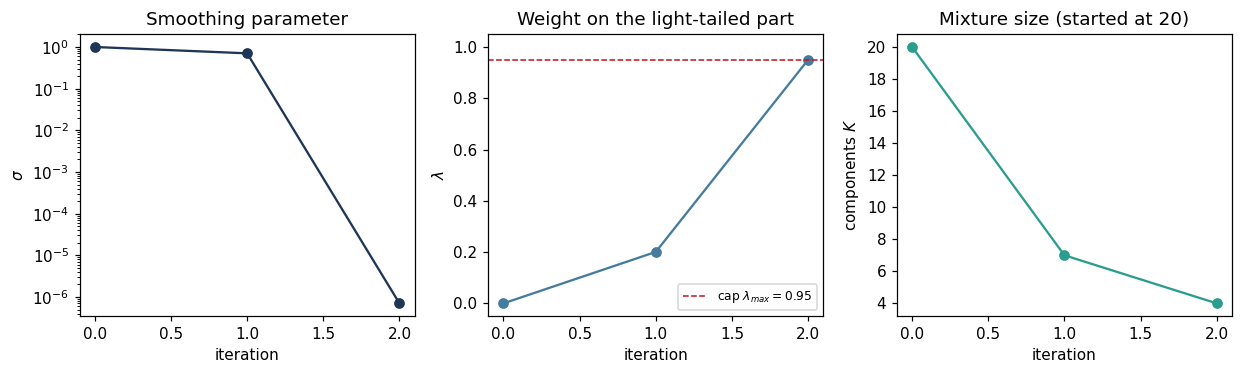

In [4]:
iters = np.arange(len(history["sigma"]))
fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.5))

axes[0].plot(iters, history["sigma"], "o-", color="#1d3557")
axes[0].set(
    xlabel="iteration", ylabel=r"$\sigma$", yscale="log", title="Smoothing parameter"
)

axes[1].plot(iters, history["lambda_val"], "o-", color="#457b9d")
axes[1].axhline(
    ice.lambda_max,
    color="#c1121f",
    ls="--",
    lw=1.0,
    label=f"cap $\\lambda_{{max}}={ice.lambda_max}$",
)
axes[1].set(
    xlabel="iteration",
    ylabel=r"$\lambda$",
    ylim=(-0.05, 1.05),
    title="Weight on the light-tailed part",
)
axes[1].legend(fontsize=8)

axes[2].plot(iters, history["components"], "o-", color="#2a9d8f")
axes[2].set(
    xlabel="iteration",
    ylabel="components $K$",
    title=f"Mixture size (started at {ice.K0})",
)

plt.tight_layout()
plt.show()

## 3. Automatic component selection

The EM step carries a cross-entropy penalty that drives redundant mixture
weights to zero, and components that reach zero are dropped. Nothing tells it
how many modes the problem has.

In [5]:
problems = [
    ("four-mode (4 lobes)", BenchmarkProblems.four_mode_series_system(z=1.0), 2),
    ("three-mode (3 lobes)", BenchmarkProblems.three_mode_problem(z=3.0), 2),
    ("two-mode (2 lobes)", BenchmarkProblems.two_mode_opposite_directions(z=3.0), 2),
    ("sphere (radially symmetric)", lambda u: 5.0 - np.linalg.norm(u, axis=-1), 10),
]

print(f"{'problem':30s} {'K0':>4s} {'final K over 5 seeds':>24s}")
print("-" * 60)
for name, g, d in problems:
    finals = []
    for seed in range(5):
        est = SafeICE(
            limit_state_function=g,
            dimension=d,
            N=1000,
            max_iterations=15,
            random_state=seed,
        )
        _pf, res = est.run(verbose=False)
        finals.append(res["final_components"])
    print(f"{name:30s} {20:4d} {finals!s:>24s}")

problem                          K0     final K over 5 seeds
------------------------------------------------------------


four-mode (4 lobes)              20          [9, 8, 8, 4, 6]


three-mode (3 lobes)             20          [7, 6, 7, 7, 7]


two-mode (2 lobes)               20          [6, 7, 7, 7, 6]


sphere (radially symmetric)      20          [4, 6, 5, 3, 3]


Every problem prunes well below the twenty it started with, and the radially
symmetric one prunes furthest. The mixture is not reduced to the exact number
of lobes — several components can share one — so this is not a mode counter.
What it does is remove components the data does not support, without being
told how many to expect. At higher dimensions the sphere goes all the way to
one component; see the dimension sweep in `03_high_dimensions.ipynb`.

## 4. The heavy-tailed safety component

The proposal is a mixture

$$q_{\text{safe}} = \lambda\, q_{\text{vMFNM}} + (1 - \lambda)\, q_{\text{heavy}}$$

The second term uses an inverse Nakagami radius, which has a heavier tail
than the Nakagami of the first. Its job is to keep the importance weights
bounded: if the proposal's tails are lighter than the target's, the ratio
$p/q$ is unbounded and a single sample can dominate the estimate.

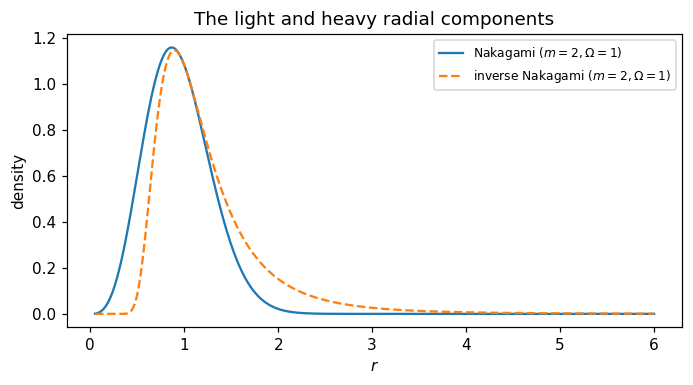

In [6]:
r = np.linspace(0.05, 6, 500)
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(r, NakagamiDistribution.pdf(r, 2.0, 1.0), label="Nakagami $(m=2, \\Omega=1)$")
ax.plot(
    r,
    InverseNakagamiDistribution.pdf(r, 2.0, 1.0),
    "--",
    label="inverse Nakagami $(m=2, \\Omega=1)$",
)
ax.set(xlabel="$r$", ylabel="density", title="The light and heavy radial components")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

$\lambda$ is annealed from 0 towards 1 as $\sigma$ falls, so a run begins by
exploring with the heavy component and ends close to the fitted mixture. It
is capped just below 1 — a deliberate departure from the paper, which lets it
reach exactly 1. At $\lambda = 1$ the safety component is gone, and on one
seed during development a single tail sample carried 99.5% of an estimate.

In [7]:
print(f"lambda_max = {ice.lambda_max}")
for sigma in (1.0, 0.5, 0.2, 0.05, 1e-8):
    print(
        f"  sigma={sigma:<8g} -> lambda={ice._cosine_annealing_schedule(sigma, ice.sigma0):.4f}"
    )

lambda_max = 0.95
  sigma=1        -> lambda=0.0000
  sigma=0.5      -> lambda=0.5000
  sigma=0.2      -> lambda=0.9045
  sigma=0.05     -> lambda=0.9500
  sigma=1e-08    -> lambda=0.9500


## The estimator itself

With the proposal fitted, the answer is an average, not a weighted mean:

$$\hat{P}_F = \frac{1}{N}\sum_i \mathbb{1}\{g(u_i) \le 0\}\,
  \frac{p(u_i)}{q_{\text{safe}}(u_i)}, \qquad u_i \sim q_{\text{safe}}$$

This is unbiased but unconstrained — nothing bounds $p/q$ by 1 — so the
returned value is clamped to $[0, 1]$, with the raw value kept alongside it.

In [8]:
print(f"failure_probability : {results['failure_probability']:.6e}")
print(f"pf_unclamped        : {results['pf_unclamped']:.6e}")
print(
    f"clamping changed it : {results['failure_probability'] != results['pf_unclamped']}"
)

failure_probability : 6.141119e-05
pf_unclamped        : 6.141119e-05
clamping changed it : False


They agree here, and on any ordinary rare-event problem: the clamp never
fires when the answer is four orders of magnitude below 1. It matters only
when the proposal fails to cover the target, and then the warning it raises
is the useful part — an estimate above 1 means the run should not be trusted,
so it is reported rather than silently rounded down.